## Triggered ripple rate

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from spyglass.shijiegu.Analysis_SGU import RippleTimesWithDecode, TrialChoice

[2025-11-07 20:32:06,033][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [6]:
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day, return_triggered_2d_position
from spyglass.shijiegu.changeOfMindRipple import triggered_ripple_animal
from spyglass.shijiegu.changeOfMind_figures.figure2_ripple import figure2_ripple_data, return_ripple_metrics

molly: decode_threshold_method = "MUA_05SD" or "MUA_M05SD"
lewis: only one is decode_threshold_method = "MUA_M05SD"

eliot: decode_threshold_method = "MUA_05SD" or "MUA_0SD"
julio: only one is decode_threshold_method = "MUA_0SD"
klein: only one is decode_threshold_method = "MUA_0SD"

#### data is generated by running
```python /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/changeOfMind_figures/figure2_ripple.py```

In [ ]:
success = {}
dates_to_plot_animals = {}
encoding_sets = {}
classifier_param_names = {}
decode_threshs = {}

animal = 'Eliot'
dates_to_plot_animals[animal] = ['20221017','20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
encoding_sets[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshs[animal] = 'MUA_0SD'

animal = 'Molly'
dates_to_plot_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
encoding_sets[animal] = '2Dheadspeed_above_4'	
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshs[animal] = 'MUA_M05SD'

animal = 'Klein'
dates_to_plot_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']
encoding_sets[animal] = '2Dheadspeed_above_4'	
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshs[animal] = 'MUA_0SD'

animal = 'Lewis'
dates_to_plot_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114']
encoding_sets[animal] = '2Dheadspeed_above_4'	
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshs[animal] = 'MUA_M05SD'

animal = 'Julio'
dates_to_plot_animals[animal] = ['20230801','20230802','20230803','20230804',
                                 '20230805','20230806','20230807','20230808',
                                 '20230809','20230810','20230811']
    
encoding_sets[animal] = '2Dheadspeed_above_4'	
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
decode_threshs[animal] = 'MUA_0SD'


for animal in ["Eliot","Klein","Lewis","Julio"]:#"#decode_threshs.keys():
    print("Processing animal:", animal)
    dates_to_plot = dates_to_plot_animals[animal]
    encoding_set = encoding_sets[animal]
    classifier_param_name = classifier_param_names[animal]
    decode_thresh = decode_threshs[animal]

    success[animal] = figure2_ripple_data(
        animal, dates_to_plot, encoding_set, classifier_param_name, decode_thresh, home_ripple = False)
    #success[animal] = figure2_ripple_data(
    #    animal, dates_to_plot, encoding_set, classifier_param_name, decode_thresh, home_ripple = True)


[13:40:41][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-09 13:40:41,800][WARNING]: Skipped checksum for file with hash: 0d661ee1-4eb4-9c8e-91b8-2f4c347f8865, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_9NQ9PCWYPI.nwb
[2025-11-09 13:40:41,821][WARNING]: Skipped checksum for file with hash: 0d661ee1-4eb4-9c8e-91b8-2f4c347f8865, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_9NQ9PCWYPI.nwb
[2025-11-09 13:40:41,827][WARNING]: Skipped checksum for file with hash: 0d661ee1-4eb4-9c8e-91b8-2f4c347f8865, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_9NQ9PCWYPI.nwb


Processing animal: Eliot
currently investigating:
02_Seq2Session1
pos 1 valid times


[2025-11-09 13:40:48,960][WARNING]: Skipped checksum for file with hash: 796da31c-5e59-029b-11dd-b7a127c5895a, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_U2N3O44TI9.nwb
[2025-11-09 13:40:48,981][WARNING]: Skipped checksum for file with hash: 796da31c-5e59-029b-11dd-b7a127c5895a, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_U2N3O44TI9.nwb
[2025-11-09 13:40:48,988][WARNING]: Skipped checksum for file with hash: 796da31c-5e59-029b-11dd-b7a127c5895a, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_U2N3O44TI9.nwb
[2025-11-09 13:40:56,803][WARNING]: Skipped checksum for file with hash: c003b9c3-4bef-30ff-d768-9fe145e0d3f3, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_Y14LCQRVHH.nwb
[13:41:01][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-09 13:41:01,967][WARNING]

02_Seq2Session1 0
currently investigating:
04_Seq2Session2
pos 3 valid times


[2025-11-09 13:41:08,835][WARNING]: Skipped checksum for file with hash: 678c0b56-0142-abda-72c7-c64b034d9c6d, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_2RTEYBOXJG.nwb
[2025-11-09 13:41:08,856][WARNING]: Skipped checksum for file with hash: 678c0b56-0142-abda-72c7-c64b034d9c6d, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_2RTEYBOXJG.nwb
[2025-11-09 13:41:08,862][WARNING]: Skipped checksum for file with hash: 678c0b56-0142-abda-72c7-c64b034d9c6d, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_2RTEYBOXJG.nwb
[2025-11-09 13:41:16,058][WARNING]: Skipped checksum for file with hash: 893894ee-33f6-4de0-1bd2-87c9ea71030a, and path: /stelmo/nwb/analysis/eliot20221017/eliot20221017_0PWMGLVHL6.nwb
[13:41:21][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-09 13:41:21,138][WARNING]

...

[2025-11-09 14:52:52,962][WARNING]: Skipped checksum for file with hash: 21ad1676-2c2f-f67b-44c5-015478220cf9, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_7455SWR3TO.nwb
[2025-11-09 14:52:52,984][WARNING]: Skipped checksum for file with hash: 21ad1676-2c2f-f67b-44c5-015478220cf9, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_7455SWR3TO.nwb
[2025-11-09 14:52:52,990][WARNING]: Skipped checksum for file with hash: 21ad1676-2c2f-f67b-44c5-015478220cf9, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_7455SWR3TO.nwb
[2025-11-09 14:52:53,089][WARNING]: Skipped checksum for file with hash: 73b224fa-a456-3128-eda0-46233d4194de, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_LW849HNSDV.nwb
[14:53:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-09 14:53:02,092][WARNING]

nearby rowID [48, 70, 81]
nearby turnaround_times [[1699212921.2882638], [1699213669.511912], [1699214023.925798]]
02_Rev2Session1 3
pre restrict time 48 1699212921.2882638
pre restrict time 70 1699213669.511912
pre restrict time 81 1699214023.925798
Finding ripple times in nearby trials.
currently investigating:
04_Rev2Session2
pos 3 valid times


[2025-11-09 14:53:02,261][WARNING]: Skipped checksum for file with hash: cbf011df-793e-e092-2f54-a13dbe9076b1, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_NRI3LQNE3B.nwb
[2025-11-09 14:53:02,282][WARNING]: Skipped checksum for file with hash: cbf011df-793e-e092-2f54-a13dbe9076b1, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_NRI3LQNE3B.nwb
[2025-11-09 14:53:02,288][WARNING]: Skipped checksum for file with hash: cbf011df-793e-e092-2f54-a13dbe9076b1, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_NRI3LQNE3B.nwb
[2025-11-09 14:53:02,390][WARNING]: Skipped checksum for file with hash: ca49e968-0f95-6475-2cfe-f0a9b97ea845, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_1XOIFN00J8.nwb
[14:53:11][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-09 14:53:11,420][WARNING]

nearby rowID [8, 17, 16, 21, 39]
nearby turnaround_times [[1699216520.971282], [1699216829.6978402], [1699216793.7848918], [1699217004.5765898], [1699217545.0228162]]
04_Rev2Session2 5
pre restrict time 8 1699216520.971282
pre restrict time 17 1699216829.6978402
pre restrict time 16 1699216793.7848918
pre restrict time 21 1699217004.5765898
pre restrict time 39 1699217545.0228162
Finding ripple times in nearby trials.
currently investigating:
06_Rev2Session3
pos 5 valid times


[2025-11-09 14:53:11,617][WARNING]: Skipped checksum for file with hash: 049d1b4a-48a1-90df-26d1-f9adfef33195, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_QJPDHHFQDX.nwb
[2025-11-09 14:53:11,639][WARNING]: Skipped checksum for file with hash: 049d1b4a-48a1-90df-26d1-f9adfef33195, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_QJPDHHFQDX.nwb
[2025-11-09 14:53:11,647][WARNING]: Skipped checksum for file with hash: 049d1b4a-48a1-90df-26d1-f9adfef33195, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_QJPDHHFQDX.nwb
[2025-11-09 14:53:11,749][WARNING]: Skipped checksum for file with hash: fd5d845f-c7d3-78ec-b15e-47337cecda1e, and path: /stelmo/nwb/analysis/klein20231105/klein20231105_5F7D3V7JPN.nwb


In [59]:
success

{'Eliot': 1, 'Klein': 1, 'Lewis': 1, 'Julio': 1}

### Plotting

In [49]:
from matplotlib.colors import Normalize
import matplotlib as mpl
import starbars
from scipy import stats
cmap = mpl.colormaps['cool']

In [50]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Molly_ripple.pickle
p_value 0.7317716100325828
p_value 0.038329603061984165
0.44000000000000006 0.03
p_value 0.442845795601387
p_value 0.2078268698093292
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Eliot_ripple.pickle
p_value 0.6841645596722696
p_value 0.24289142187409424
p_value 0.005738111159536532
1.54 0.03
p_value 0.0908131120246554
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Klein_ripple.pickle
p_value 0.10336552226729794
p_value 0.26384736059830005
p_value 0.005473814393483849
2.64 0.03
p_value 0.0002575779325177609
2.64 0.03
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Lewis_ripple.pickle
p_value 5.3834558855024906e-05
3.7399999999999998 0.03
p_value 0.0014527844180530593
3.7399999999999998 0.03
p_value 1.207305101357798e-05
3.7399999999999998 0.03
p_value 0.01286346338429059
3.7399999999999998 0.03
Data su

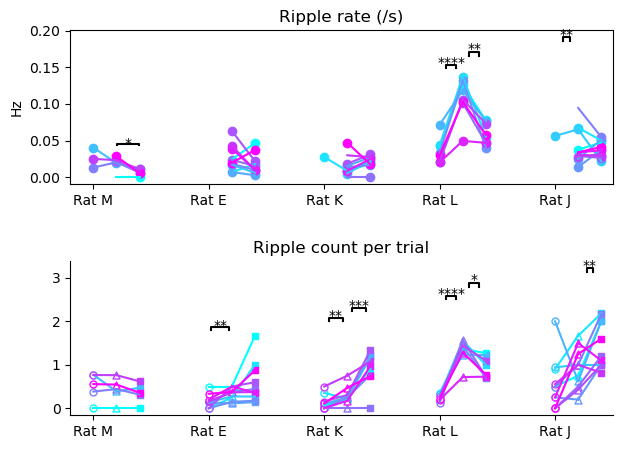

In [71]:
fig,axes = plt.subplots(2,1,figsize = (7,5))
plt.subplots_adjust(wspace=0.8, hspace=0.5)

animal_ind = 0
animals = ["Molly","Eliot",'Klein',"Lewis","Julio"]#,"Klein","Lewis1","Julio"]
both_flag = True
home_ripple = False
version_main_text = False

for animal in animals:

    if home_ripple:
        file_path = f"{output_folder}/{animal[:5]}_home_ripple.pickle"
    else:
        file_path = f"{output_folder}/{animal[:5]}_ripple.pickle"
    
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

    dates_to_plot = list(data["ranges"].keys())
    

    norm = Normalize(vmin=0, vmax=len(dates_to_plot)-1)

    ratio1, ratio2, ratio3 = [], [], []
    count1, count2, count3 = [], [], []
    for d_ind in range(len(dates_to_plot)):
        d = dates_to_plot[d_ind]

        (ratio, ratio_nearby, ratio_nearby_rewarded,
             ripple_num, ripple_num_nearby, ripple_num_nearby_rewarded) = return_ripple_metrics(data, d, both_flag)

        
        ratio1.append(ratio)
        ratio2.append(ratio_nearby)
        ratio3.append(ratio_nearby_rewarded)

        count1.append(ripple_num)
        count2.append(ripple_num_nearby)
        count3.append(ripple_num_nearby_rewarded)

        axe = axes[0]
        if len(data["ranges"][d]) >= 5:
            axe.scatter(np.zeros_like(ratio) + animal_ind, ratio, color = cmap(norm(d_ind)))
        if len(data["ranges_nearby"][d]) >= 5:
            axe.scatter(np.zeros_like(ratio_nearby) + animal_ind + 0.2, ratio_nearby, color = cmap(norm(d_ind)))
        if len(data["ranges"][d]) >= 5 and len(data["ranges_nearby"][d]) >= 5:
            axe.plot(np.array([0,0.2]) + animal_ind,[ratio, ratio_nearby],color = cmap(norm(d_ind)))
        
        if not version_main_text:
            axe.scatter(np.zeros_like(ratio_nearby_rewarded) + animal_ind + 0.4, ratio_nearby_rewarded, color = cmap(norm(d_ind)))
            axe.plot(np.array([0.2,0.4]) + animal_ind,[ratio_nearby, ratio_nearby_rewarded],color = cmap(norm(d_ind)))

        axe = axes[1]
        dot_size = 25
        axe.scatter(np.zeros_like(ripple_num) + animal_ind, ripple_num,
                    edgecolor = cmap(norm(d_ind)), facecolor = 'white', s = dot_size, marker = "o")
        axe.scatter(np.zeros_like(ripple_num_nearby) + animal_ind + 0.2, ripple_num_nearby,
                    edgecolor = cmap(norm(d_ind)), facecolor = 'white', s = dot_size, marker = "^")
        axe.plot(np.array([0,0.2]) + animal_ind,[ripple_num, ripple_num_nearby],
                    color = cmap(norm(d_ind)))

        if not version_main_text:
            axe.scatter(np.zeros_like(ripple_num_nearby_rewarded) + animal_ind + 0.4, ripple_num_nearby_rewarded,
                        facecolor = cmap(norm(d_ind)), s = dot_size, marker = "s")
            axe.plot(np.array([0.2,0.4]) + animal_ind,[ripple_num_nearby, ripple_num_nearby_rewarded],color = cmap(norm(d_ind)))
        

    #### add stats
    t_statistic, p_value = stats.ttest_rel(ratio1, ratio2)
    print("p_value", p_value)
    if p_value < 0.05:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.2, np.round(p_value, 4))],ax = axes[0])

    if not version_main_text:
        t_statistic, p_value = stats.ttest_rel(ratio2, ratio3)
        print("p_value", p_value)
        if p_value < 0.05:
            starbars.draw_annotation([(animal_ind + 0.2, animal_ind + 0.4, np.round(p_value, 4))],ax = axes[0])

    t_statistic, p_value = stats.ttest_rel(count1, count2)
    print("p_value", p_value)
    if p_value < 0.05:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.2, np.round(p_value, 4))],ax = axes[1])

    if not version_main_text:
        t_statistic, p_value = stats.ttest_rel(count2, count3)
        print("p_value", p_value)
        if p_value < 0.05:
            starbars.draw_annotation([(animal_ind + 0.2, animal_ind + 0.4, np.round(p_value, 4))],ax = axes[1])
    ########

    animal_ind += 1


axes[0].set_xticks(np.arange(len(animals)));
axes[0].set_xticklabels(["Rat " + animal[0] for animal in animals]);
axes[0].set_xlim([-0.2,len(animals)-0.5]);
#axes[0].set_ylim([0,0.2])
if home_ripple:
    axes[0].set_title("Ripple rate at home well (/s)")
else:
    axes[0].set_title("Ripple rate (/s)")
axes[0].set_ylabel("Hz")

axes[1].set_xticks(np.arange(len(animals)));
axes[1].set_xticklabels(["Rat " + animal[0] for animal in animals]);
axes[1].set_xlim([-0.2,len(animals)-0.5]);
axes[1].set_title("Ripple count per trial")
axes[1].set_ylabel("")
axes[1].spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure2/"
if both_flag:
    prefix = "preANDpost"
else:
    prefix = "preCoM"
if version_main_text:
    plt.savefig(file_path + f"ripple_maintext_both_flag_{int(both_flag)}_home{int(home_ripple)}.pdf")
    plt.savefig(file_path + f"ripple_maintext_both_flag_{int(both_flag)}_home{int(home_ripple)}.png")
else:
    plt.savefig(file_path + f"ripple_{prefix}_{int(both_flag)}_home{int(home_ripple)}.pdf",bbox_inches='tight')
    plt.savefig(file_path + f"ripple_{prefix}_{int(both_flag)}_home{int(home_ripple)}.png")

In [52]:
%debug

> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/changeOfMind_figures/figure2_ripple.py(62)return_ripple_metrics()
     60 
     61     trial_num = len(np.unique(data["session_names"][d]))
---> 62     assert 1 == 0
     63     trial_num_nearby = len(data["session_names_nearby"][d])
     64     trial_num_nearby_rewarded = len(data["session_names_nearby_rewarded"][d])



ipdb>  data.keys()


dict_keys(['ripple_ind', 'ripple_ind_both', 'ripple_ind_nearby', 'ripple_ind_nearby_rewarded', 'session_names', 'session_names_both', 'session_names_nearby', 'session_names_nearby_rewarded', 'ranges', 'ranges_both', 'ranges_nearby', 'ranges_nearby_rewarded', 'durations', 'durations_both', 'durations_nearby', 'durations_nearby_rewarded', 'trialID', 'trialID_both', 'trialID_nearby', 'trialID_nearby_rewarded'])


ipdb>  data["trialID"][d]


[]


ipdb>  data["trialID"]


{'20220416': [], '20220417': array([15, 36, 39, 43, 50, 55, 73, 80]), '20220418': array([28, 32, 43, 50, 53, 12, 17, 23, 25, 29, 31, 35, 39, 48, 53, 71]), '20220419': array([12, 32, 45, 52, 59, 60, 76, 21, 23, 24, 38, 46, 50, 67,  8, 50, 71]), '20220420': array([ 8, 30, 73, 76])}


ipdb>  exit


## End here

In [199]:
animal = "Molly"
dates_to_plot = ['20220416','20220417','20220418','20220419','20220420']
encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
decode_thresh = "MUA_05SD"


success["Molly"] = figure2_ripple_data(animal, dates_to_plot, encoding_set, classifier_param_name, decode_thresh)

NameError: name 'figure2_ripple_data' is not defined

In [ ]:
RippleTimesWithDecode() & key

In [ ]:
ranges, ripple_ind, session_names, ranges_nearby, ripple_ind_nearby, session_names_nearby = ({}, {}, {}, {}, {}, {})

#######
animal = 'Eliot'
#dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
dates_to_plot = ['20221017','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
    
encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'
decode_thresh = 'MUA_0SD'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(ranges[animal], ripple_ind[animal], session_names[animal],
    ranges_nearby[animal], ripple_ind_nearby[animal], session_names_nearby[animal]) = triggered_ripple_animal(
    animal, dates_to_plot, encoding_set, classifier_param_name, decode_thresh, post = False)

#######
animal = 'Lewis'
dates_to_plot = ['20240104','20240105','20240106','20240107','20240108','20240109', #['20240102','20240103','20240104','20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114']#'20240115','20240116','20240117','20240118','20240119','20240120']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
decode_thresh = 'MUA_M05SD'
(ranges[animal], ripple_ind[animal], session_names[animal],
    ranges_nearby[animal], ripple_ind_nearby[animal], session_names_nearby[animal]) = triggered_ripple_animal(
    animal, dates_to_plot, encoding_set, classifier_param_name, decode_thresh, post = False)

In [64]:
### data making

output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'

for animal in days.keys():
    day = days[animal]
    encoding_set = encoding_sets[animal]
    classifier_param_name = classifier_param_names[animal]

    data = {}
    data["positions"], data["positions_2D"], data["positions_control"], data["positions_2D_control"] = figure_speed_data(
        animal, day, encoding_set, classifier_param_name)

    file_path = f"{output_folder}/{animal}_speed.pickle"
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")
    

[2025-10-09 10:38:50,593][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:50,605][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:50,611][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:50,703][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:50,715][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:50,719][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/mol

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220418_p0.1_tm5_tp5_maxflag0_controlFalse_allposterior.pkl':


[2025-10-09 10:38:50,838][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:50,848][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:50,853][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:51,067][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:51,082][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:51,087][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/mol

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220418_p0.1_tm5_tp5_maxflag0_controlTrue_allposterior.pkl':


[2025-10-09 10:38:56,454][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:56,463][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:56,466][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:56,549][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:56,560][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:38:56,565][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/mol

...

[2025-10-09 10:39:00,446][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:39:00,542][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:39:00,559][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:39:00,564][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:39:00,647][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:39:00,656][WARNING]: Skipped checksum for file with hash: 5c

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/eliot_triggered_position_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221021_p0.1_tm5_tp5_maxflag0_controlTrue_allposterior.pkl':


[2025-10-09 10:39:04,665][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:39:04,679][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:39:04,683][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:39:04,762][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:39:04,777][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:39:04,781][WARNING]: Skipped checksum for file with hash: 5c

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/Eliot_speed.pickle


FileNotFoundError: [Errno 2] No such file or directory: '/stelmo/shijie/change_of_mind_analysis/klein_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231107_p0.1_tm5_tp5_maxflag0_controlFalse_allposterior.pkl'

[2025-10-09 10:29:06,818][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:06,838][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:06,843][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220418_p0.1_tm5_tp5_maxflag0_controlFalse_allposterior.pkl':


[2025-10-09 10:29:06,985][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:07,004][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:07,009][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:07,164][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:07,182][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:07,188][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/mol

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220418_p0.1_tm5_tp5_maxflag0_controlTrue_allposterior.pkl':


[2025-10-09 10:29:11,590][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:11,610][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:11,615][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:11,692][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:11,711][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/molly20220418_FAQ8CMQ1N0.nwb
[2025-10-09 10:29:11,717][WARNING]: Skipped checksum for file with hash: f2937c39-6ec7-9194-f4c5-2d2c8dc8d2bb, and path: /stelmo/nwb/analysis/mol

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/eliot_triggered_position_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221021_p0.1_tm5_tp5_maxflag0_controlFalse_allposterior.pkl':


[2025-10-09 10:29:26,251][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:29:26,275][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:29:26,283][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:29:26,404][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:29:26,426][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:29:26,434][WARNING]: Skipped checksum for file with hash: 5c

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/eliot_triggered_position_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221021_p0.1_tm5_tp5_maxflag0_controlTrue_allposterior.pkl':


[2025-10-09 10:29:50,675][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:29:50,690][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:29:50,694][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:29:50,782][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:29:50,798][WARNING]: Skipped checksum for file with hash: 5c7f6b45-0583-e0a0-1f8f-f95c61529e53, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_IF49RQFH3I.nwb
[2025-10-09 10:29:50,803][WARNING]: Skipped checksum for file with hash: 5c

FileNotFoundError: [Errno 2] No such file or directory: '/stelmo/shijie/change_of_mind_analysis/klein_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231107_p0.1_tm5_tp5_maxflag0_controlFalse_allposterior.pkl'

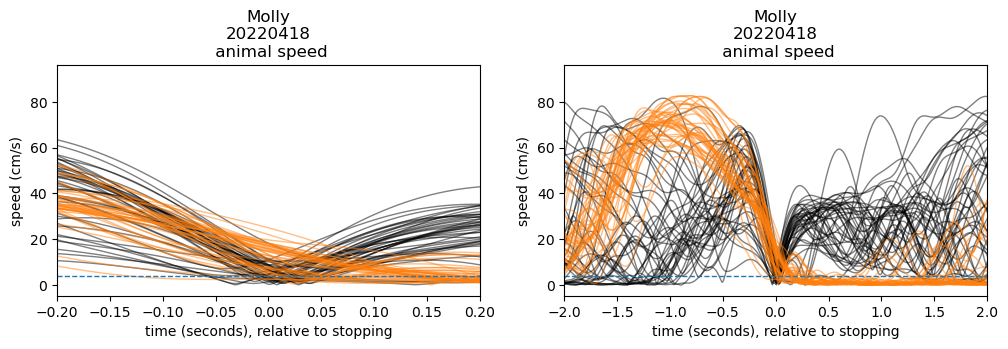

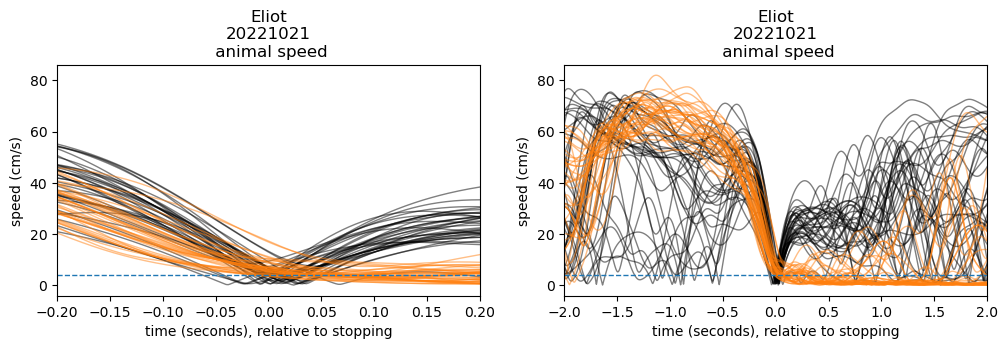

In [63]:
### data plotting
for animal in days.keys():
    day = days[animal]
    encoding_set = encoding_sets[animal]
    classifier_param_name = classifier_param_names[animal]
    
    file_path = f"{output_folder}/{animal}_speed.pickle"
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")
        
    figure_speed_plot(data["positions"], data["positions_2D"], data["positions_control"], data["positions_2D_control"])

Text(0, 0.5, 'speed (cm/s)')

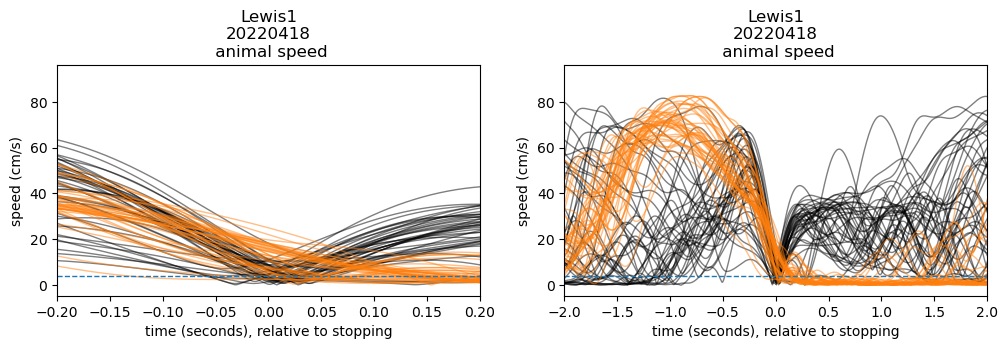

In [59]:
speed = figure_speed(positions, positions_2D, positions_control, positions_2D_control)

In [52]:
(positions, positions_abs, decodes, decodes_abs) = (triggered_positions[animal], triggered_positions_abs[animal],
     triggered_decodes[animal], triggered_decodes_baseoff[animal])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5),sharex=True)

for position in positions:
    ax1.plot(position, linewidth = 1, alpha = 0.5, color = 'k')

row_ind = 0
for rendition_ind in range(len(positions_abs)):
    position_abs = positions_abs[rendition_ind]
    position = positions[rendition_ind]
    decode_abs = decodes_abs[rendition_ind]
    if len(position_abs) == len(decode_abs):
        ax2.plot(position.index, np.array(decode_abs) - np.array(position_abs), linewidth = 1, alpha = 0.5, color = 'k')
    row_ind = row_ind + 1

ax1.set_title(animal + "\n animal position relative to stopping")
ax2.set_title("decoded position relative to physical location")

ax1.set_ylabel("linearized location (cm)")
ax2.set_xlabel("time (seconds)")
ax2.set_ylabel("linearized location (cm)")

NameError: name 'triggered_positions' is not defined